<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Mecanica-de-medios-continuos/MCON_TareaNumericaOpcional_ChoquePlanetasSPH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p>
<h1><b><center></center></b></h1>
<center><img src="https://drive.google.com/uc?id=1UJc1ci41G6ahJ7ProKvunUOIBcTXZ6ZG" align="center" width="550"></center>
</p>
<h1><b><center>Mecánica Celeste</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Tarea Numérica Opcional</center></b><h2>
<h3><b><center>Choque de Planetas</center></b><h3>
<h5><center><b>Asignada</b>: 20 de Junio de 2024</center><h5>
<h5><center><b>Entrega</b>: (Por definir)</center><h5>
</p>

<hr/>
<b>Nombre</b>: Juan Manuel Cardenas
<br/>
<b>Cédula</b>: 1002587562
<br/>
<b>Última actualización</b>: 15/7/24
<hr/>
<br>
Importando Librerias:

In [ ]:
!pip install -q celluloid

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
from celluloid import Camera
from tqdm import tqdm
from scipy.signal import argrelextrema as extrem

**Objetivo**:
El objetivo de esta tarea es estudiar el choque de dos planetas usando para ello el código de SPH desarrollado durante la última clase.




___

## **Definicion de Funciones SPH**



**Kernel y su gradiente**:

In [ ]:
def W( x, y, z, h ):
	"""Kernel Gaussiano"""
	r = np.sqrt(x**2 + y**2 + z**2)
	w = (1.0/(h*np.sqrt(np.pi)))**3*np.exp(-r**2/h**2)
	return w

def gradW( x, y, z, h ):
	"""Gradiente del kernel gaussiano"""
	r = np.sqrt(x**2 + y**2 + z**2)
	n = -2*np.exp(-r**2/h**2)/h**5/(np.pi)**(3/2)
	wx = n*x
	wy = n*y
	wz = n*z
	return wx, wy, wz

En las fórmulas de SPH es necesario calcular el Kernel que típicamente depende de la distancia entre las partículas:

$$
<f\left(\boldsymbol{x}_i\right)>=\sum_{j=1}^N \frac{m_j}{\rho_j} f\left(\boldsymbol{x}_j\right) \cdot W_{i j}
$$
donde: $W_{ij} = W\left(\boldsymbol{x}_i-\boldsymbol{x}_j, h\right)$

Necesitamos entonces una rutina para calcular la distancia entre todas las partículas, esta rutina lo hace, y lo mejor, lo hace de la forma más eficiente posible usando para ello herramientas disponibles en `numpy`:


In [ ]:
def vectores_relativos(ri, rj):
	"""Obtiene vectores relativos entre partículas
  Recibe:
    ri: Matriz M x 3 con posición de partículas
    rj: Matriz N x 3 con posición de otras partículas

  Devuelve:
    dx, dy, dz: Matrices M x N con las separaciones entre partículas
	"""
	M = ri.shape[0]
	N = rj.shape[0]

	# Obtiene las componentes x,y,z de las posiciones
	rix = ri[:,0].reshape((M,1))
	riy = ri[:,1].reshape((M,1))
	riz = ri[:,2].reshape((M,1))
	rjx = rj[:,0].reshape((N,1))
	rjy = rj[:,1].reshape((N,1))
	rjz = rj[:,2].reshape((N,1))

	# Vectores relativos
	dx = rix - rjx.T
	dy = riy - rjy.T
	dz = riz - rjz.T

	return dx, dy, dz

Los campos de **Densidad** y **Presión**:

In [ ]:
def densidad(r, pos, m, h):
    """Obtiene el valor del campo de densidad en posición r
  Recibe:
    r:   matriz M x 3 donde se quiere calcular el campo
    pos: matiz N x 3 donde están las partículas de SPH
    m:   masa de las partículas de SPH
    h:   longitud de suavizado o soporte del kernel

  Devuelve:
    rho: Vector M x 1 de densidades
    """
    M = r.shape[0]
    dx, dy, dz = vectores_relativos(r, pos);
    rho = np.sum(m*W(dx,dy,dz,h),1).reshape((M,1))

    return rho

def presion(rho, k, gamma):
    """ Ecuación de estado politrópica del medio
  Recibe:
    rho: valor o vector de densidades:
    k:   constante de la ecuación de estado
    n:   índice politrópico

  Devuelve:
    P:   valor o vector de presiones
    """
    P = k*rho**(1+1/gamma)
    return P

### **Ecuaciones de Movimiento**: aceleracion

la versión Lagrangiana de la ecuación de Navier-Stokes. Usando un modelo simple de viscosidad introducida con la prescripción $\vec F \propto -\nu\vec v$. Para las fuerzas entre las partículas asumiremos que se atraen (o repelen) como si hubiera resortes entre ellas. Este modelo es útil para simular cuerpos físicos autogravitantes como se demuestra en el artículo citado al principio:

In [ ]:
def aceleracion(pos, vel, m, h, k, gamma, phi, nu):
  """Calcula la aceleración de cada partícula
  Recibe:
    pos: matriz N x 3 con posiciones de partículas
    vel: matriz N x 3 con velocidades de partículas
    m:   masa de cada partícula
    h:   longitud de suavizado
    k,gamma: parametros de ec de estado
    phi: cte del potencial externo
    nu:  cte de viscosidad

  Devuelve:
    a: matriz N x 3 con aceleraciones de partículas
  """
  # Número de partículas
  N = pos.shape[0]

  # calculo de Desnsidades
  rho = densidad(pos, pos, m, h)

  # calculo de Presiones
  P = presion(rho, k, gamma)

  # Vectores relativos
  dx, dy, dz = vectores_relativos(pos, pos)
  dWx, dWy, dWz = gradW(dx, dy, dz, h) # Gradiente del kernel

  # Ecuacion de movimiento: termino de presión
  ax = -np.sum(m*(P/rho**2+P.T/rho.T**2)*dWx,1).reshape((N,1))
  ay = -np.sum(m*(P/rho**2+P.T/rho.T**2)*dWy,1).reshape((N,1))
  az = -np.sum(m*(P/rho**2+P.T/rho.T**2)*dWz,1).reshape((N,1))
  a = np.hstack((ax,ay,az)) # juntando aceleraciones

  # contribución de viscosidad
  a -= nu*vel

  # static gravitational potential
  a -= phi * pos

  return a

#### **Condiciones iniciales**

In [ ]:
def reinicia_condiciones_iniciales(N):
  """Genera posiciones y velocidades iniciales"""
  pos = np.random.randn(N,3)
  vel = np.zeros_like(pos)
  return pos, vel

<br><br>
___

## **Desarrollo**

___

### **1. Condiciones iniciales  planeta Mayor**
1. **Cálculo de condiciones iniciales del planeta mayor**. Usando el código visto en clase calcule las posiciones y velocidades finales de una nube de pseudo partículas con una masa total $M = 2$ y $N = 500$. Integre el movimiento hasta que la velocidad promedio de las partículas este por debajo de una cierta tolerancia, es decir, hasta que estén prácticamente quietas. Al alcanzar ese estado almacene las posiciones y velocidades de las partículas.




**Propiedades del planeta mayor**

Por notacion en el codigo este sera el planeta 1.



In [ ]:
# Propiedades del medio
M = 2     # masa
N = 500   # particulas
k = 0.1   # cte ec estado
gamma = 1 # indice adiabatico
phi = 2   # constante de la fuerza del medio
nu = 2    # visosidad modelada

# Propiedades SPH
m = M/N   # masa de cada particula
h = 0.1   # long suavizado

#### **Ciclo evolucion de particulas**: planeta mayor (1)

Usando el codigo visto en clase, la velocidad de tolerancia para el equilibrio hidrostatico se elgio visualmente de la grafica de las velocidades promedio de las celdas siguientes. tendiendo casi al final de la evolucion del sistema donde la velocidad promedio tendia a estabilizarse.

Las posiciones y velocidades de las particulas se guardaran en listas (en Mayusculas para indicar vectoriales, y minusculas escalares) a partir desde que se de la condicion de velocidad menor a la de tolerancia. Asi, el primer elemento de la lista de posicion y velocidad seran las condiciones iniciales de los planetas de la simulacion del choque


In [ ]:
# ICS
pos, vel = reinicia_condiciones_iniciales(N)

# guarda datos
vels = []  # magnitud velocidad promedio
radii = [] # radio aprox del planeta
POS = []; VELS = [] # posicion y velocidad vectorial


dt = 0.05    # paso de tiempo
v_tol = 0.5  # velocidad de tolerancia
n_iter = 100 # numero de iteraciones

for i in tqdm(range(n_iter)): # integracion

  # Metodo Verlet
  a = aceleracion(pos, vel, m, h, k, gamma, phi, nu)
  vel += a*dt/2
  pos += vel*dt
  a = aceleracion(pos, vel, m, h, k, gamma, phi, nu)
  vel += a*dt/2

  # velocidad
  vels.append(np.linalg.norm(vel))

  # Equilibrio Hidrostatico
  if vels[i] < v_tol:
    POS.append(pos)
    VELS.append(vel)
    radii.append(max(np.linalg.norm(pos, axis=1))) # radio aprox


POS = np.array(POS)
VELS = np.array(VELS)

100%|██████████| 100/100 [00:11<00:00,  8.64it/s]


___

### **2. Condiciones iniciales  planeta Menor**
2. **Cálculo de condiciones iniciales del planeta menor**. Repita el procedimiento anterior usando $M = 1$ y $N = 250$, pero en este caso disminuya el valor del parámetro `k` en la ecuación de estado hasta que el radio de la nube de partículas sea cerca de la mitad del tamaño del planeta mayor.  Es importante tener en cuenta que este valor de `k` debe ser almacenado y ser usado en el calculo de la aceleración cuando los dos conjuntos de partículas se fusionen.

Por notacion en el codigo este sera el planeta 2. Las variables y propiedades para este planeta se acuñaran con un 2 al final de cada variable para diferenciarlas del planeta 1.

Debido a la seleccion del numero de particulas y la masa total de los cuerpos, la masa individual de cada particula es la misma para ambos cuerpos.

In [ ]:
# Propiedades del medio
M2 = 1    # masa
N2 = 250  # particulas
k2 = 0.01 # cte ec estado
gamma = 1 # indice adiabatico
phi = 2   # cte de la fuerza del medio
nu = 2    # visosidad modelada

# Propiedades SPH
m2 = M2/N2 # masa de cada particula
h = 0.1    # long suavizado

#### **Ciclo evolucion de particulas**: planeta menor (2)

Las posiciones y velocidades para las condiciones iniciales del planeta 2 se guardaran del mismo modo que se hizo para el planeta 1.

In [ ]:
pos2, vel2 = reinicia_condiciones_iniciales(N2)

# guarda datos
vels2 = []; radii2 = []; POS2 = []; VELS2 = []


for i in tqdm(range(n_iter)): # integracion

  # Metodo Verlet
  a = aceleracion(pos2, vel2, m2, h, k2, gamma, phi, nu)
  vel2 += a*dt/2
  pos2 += vel2*dt
  a = aceleracion(pos2, vel2, m2, h, k2, gamma, phi, nu)
  vel2 += a*dt/2

  # velocidad
  vels2.append(np.linalg.norm(vel2))

  # Equilibrio Hidrostatico
  if vels2[i] < v_tol:

    VELS2.append(vel2)
    POS2.append(pos2)
    radii2.append(max(np.linalg.norm(pos2, axis=1))) # radio aprox

POS2 = np.array(POS2)
VELS2 = np.array(VELS2)

100%|██████████| 100/100 [00:02<00:00, 44.76it/s]


**Velocidad promedio** de las particulas y **razon entre los radios** de ambos planetas

Razon entre los radios de los planetas: 1.99



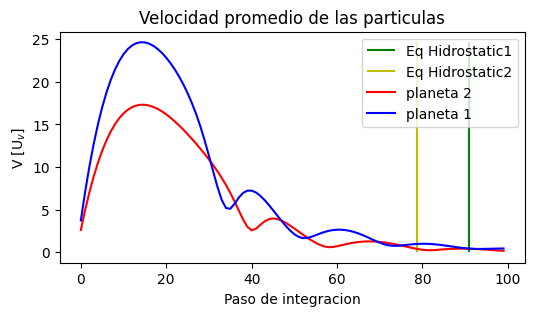

In [ ]:
print(f'Razon entre los radios de los planetas: {radii[0]/radii2[0]:.2f}\n')

# paso de integracion
iter = np.linspace(0,100,100)

# grafica velocidad prom
fig = plt.figure(figsize=(6,3))
plt.title('Velocidad promedio de las particulas')
plt.vlines(iter[-len(POS)], 0,max(vels), label='Eq Hidrostatic1',colors='g')
plt.vlines(iter[-len(POS2)], 0,max(vels), label='Eq Hidrostatic2',colors='y')
plt.plot(vels2, 'r', label='planeta 2')
plt.plot(vels, 'b', label='planeta 1')
plt.xlabel('Paso de integracion')
plt.ylabel('V [U$_v$]')
plt.legend()
plt.show()

___
### **3. Condiciones iniciales del choque**
3. **Condiciones iniciales del choque**. En una simulación nueva carge las posiciones y velocidades almacenadas previaments. El primer conjunto de posiciones y velocidades (planeta mayor) quedaran iguales. El segundo conjunto de posiciones ubiquelo desplazando las posiciones al punto $[2,1,0]$. Una vez allí, fije la velocidad de todas las partículas iguales a $[-2,0,0]$. Grafique las condiciones iniciales y verifique la situación inicial del choque.

Redefinicion de las condiciones iniciales del segundo planeta; situando al segundo planeta en la posicion $[2,1,0]$ respecto al origen, y con solo componente de velocidad en $x$ negativa, dirigiendo el planeta 2 hacia el 1

In [ ]:
# reubicacion del planeta 2
POS2[0] = POS2[0] + [2,1,0]

# velocidades nuevas del planeta 2
VELS2 = np.zeros_like(POS2[0])
VELS2[:,0] = -2

#### **grafica de las posiciones iniciales de ambos planetas**

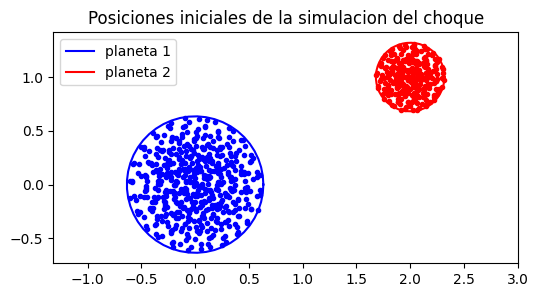

In [ ]:
# radios aparentes de los planetas
angls = np.linspace(0,2*np.pi,50)
x1 = radii[0]*np.cos(angls)
y1 = radii[0]*np.sin(angls)
x2 = radii2[0]*np.cos(angls) + 2
y2 = radii2[0]*np.sin(angls) + 1

# grafica ICS del choque
plt.figure(figsize=(6,3))
plt.title('Posiciones iniciales de la simulacion del choque')
plt.plot(POS[0][:,0], POS[0][:,1], 'b.')
plt.plot(POS2[0][:,0], POS2[0][:,1], 'r.')
plt.plot(x1, y1, 'b', label='planeta 1')
plt.plot(x2, y2, 'r', label='planeta 2')
plt.axis('equal')
plt.legend()
plt.show()

___
### **4. Simulacion del choque**
4. **Integración del choque**. Integre el sistema garantizando que el valor usado para `k` sea diferente para las partículas que estaban originalmente en el planeta mayor y para las partículas del planeta menor. Cambie las condiciones iniciales hasta obtener unas condiciones de choque que parezcan interesantes.

### **Modificacion de funciones**: varios planetas

Para conservar la distincion de la composicion de cada cuerpo, se crea una funcion alterna de la presion (que es donde el parametro k cambia dependiendo el planeta) que calcula la presion dependiendo de a que cuerpo pertenece la particula. Para esto, las condiciones iniciales se crean con un arreglo que contiene en orden los datos de las particulas, de modo que se pueden clasificar por el tamaño que inicialmente tenia cada planeta.

Esta separacion se deberia hacer con otras funciones si los parametros cambiasen, pero como solo cambia k en este caso no fue necesario. Con la nueva funcion de presion, se debe cambiar tambien la aceleracion pues esta depende de la presion.

In [ ]:
def presion_mod(rho, k, gamma, num1, num2):
    """ Ecuación de estado politrópica del medio
        para 2 cuerpos distintos
  Recibe:
    rho: valor o vector de densidades:
    k:   cte de ecuación de estado (lista)
    n:   índice politrópico
    num1: numero de particulas cuerpo 1
    num2: numero de particulas cuerpo 2
  Devuelve:
    P:   valor o vector de presiones
    """
    P = np.zeros_like(rho)
    # presion planeta 1
    P[:num1] = k[0]*rho[:num1]**(1+1/gamma)
    # presion planeta 2
    P[num1:] = k[1]*rho[num1:]**(1+1/gamma)
    return P


def aceleracion_mod(pos, vel, m, h, k, gamma, phi, nu):
  """Calcula la aceleración de cada partícula
  Recibe:
    pos: matriz N x 3 con posiciones de partículas
    vel: matriz N x 3 con velocidades de partículas
    m:   masa de cada partícula
    h:   longitud de suavizado
    k,gamma: parametros de ec de estado
    phi: cte del potencial externo
    nu:  cte de viscosidad
  Devuelve:
    a: matriz N x 3 con aceleraciones de partículas
  """
  # Número de partículas
  N = pos.shape[0]

  # calculo de Desnsidades
  rho = densidad(pos, pos, m, h)

  # calculo de Presiones (para ambos cuerpos)
  P = presion_mod(rho, k, gamma, num1, num2)

  # Vectores relativos
  dx, dy, dz = vectores_relativos(pos, pos)
  dWx, dWy, dWz = gradW(dx, dy, dz, h) # Gradiente del kernel

  # Ecuacion de movimiento: termino de presión
  ax = -np.sum(m*(P/rho**2+P.T/rho.T**2)*dWx,1).reshape((N,1))
  ay = -np.sum(m*(P/rho**2+P.T/rho.T**2)*dWy,1).reshape((N,1))
  az = -np.sum(m*(P/rho**2+P.T/rho.T**2)*dWz,1).reshape((N,1))
  a = np.hstack((ax,ay,az)) # juntando aceleraciones

  # contribución de viscosidad
  a -= nu*vel
  # static gravitational potential
  a -= phi * pos

  return a

**Modificando las condiciones iniciales del sistema 2 planetas**

Tras varios intentos, se decidio cambiar la componente de la velocidad en $x$ y $y$ de todas las particulas del planeta 2, dandole mas velocidad para mostrar que comportamiento tenian las particulas que componen ambos planetas



In [ ]:
# velocidades nuevas del planeta 2
VELS2 = np.zeros_like(POS2[0])
VELS2[:,0] = -6.6
VELS2[:,1] = -1.4

**Parametros para la simulacion del choque**

combinando las posiciones y velocidades de las particulas de los dos planetas en arreglos, y asignando las condiciones iniciales.

In [ ]:
# numero de particulas por planeta
num1 = len(POS[0])
num2 = len(POS2[0])

# posiciones y velocidades nuevas
poss = np.zeros((num1+num2,3))
vels = np.zeros((num1+num2,3))

# asignando posiciones
poss[:num1] = POS[0]
poss[num1:] = POS2[0]

# asignando velocidades
vels[:num1] = VELS[0]
vels[num1:] = VELS2

### **Grafica del choque de los dos planetas**

Usando el mismo ciclo para la integracion SPH, ahora para el conjunto de los dos planetas:

In [ ]:
# Grafica
fig, ax = plt.subplots()
ax.set_aspect('equal', 'box')
ax.set_facecolor('black')
ax.set_facecolor((.1,.1,.1))
camera = Camera(fig)


K = [k,k2] # constantes de ecuacion de estado

dt = 0.05   # paso de tiempo

for i in tqdm(range(n_iter)): # integracion

  # Metodo Verlet
  a = aceleracion_mod(poss, vels, m, h, K, gamma, phi, nu)
  vels += a*dt/2
  poss += vels*dt
  a = aceleracion_mod(poss, vels, m, h, K, gamma, phi, nu)
  vels += a*dt/2

  # densidad
  rho = densidad(poss, poss, m, h)

  # grafica movimiento
  plt.scatter(poss[:,0],poss[:,1],c=rho,cmap='autumn',s=10,alpha=0.5)
  camera.snap()
plt.close()

100%|██████████| 100/100 [00:19<00:00,  5.23it/s]


### **Animacion del choque de los dos planetas**

In [ ]:
anim = camera.animate()
HTML(anim.to_html5_video())

La idea de aumentar la velocidad del planeta 2 era para ver si las particulas de alguno de los dos cuerpos se llegaba a separar por el impacto, que lograra parecerse a una de las tantas simulaciones de colision planetaria. No obstante no sucedio, lo que puede deberse a la naturaleza del potencial armonico entre las particulas.

Tambien se puede observar que despues del primer impacto de los dos planetas, el segundo impacto tiene caracteristicas de una especie de balistica, tal vez se pueda simular sistemas de este tipo cambiando las propiedades y la geometria de los cuerpos, incluso el potencial.

Mientras que al final de la simulacion, la union de los dos planetas evoca algo similar a la interaccion de celulas.


<br><br>
___

**Resultados esperados**:

- Este notebook con el procedimiento debidamente comentado.

- Gráficos esperados:
  - Una animación de la colisión.

- En caso de utilizar ayudas como `ChatGPT` o códigos de `Stack Over Flow` debe citar debidamente la fuente, pero también entender a cabalidad el código, el profesor puede pedir justificación.